
# Laboratorio 02: Implementación de Métodos de Aprendizaje Supervisado

**Curso:** Inteligencia Artificial  
**Fecha:** 23 Febrero 2026

En este laboratorio vamos a implementar varios métodos de aprendizaje supervisado, incluyendo clasificadores bayesianos (óptimo y Naïve Bayes) y Regresión Logística. Aplicaremos estos conceptos a problemas teóricos de probabilidad, a un pequeño conjunto de datos (Play Golf) y, finalmente, construiremos un clasificador NLP para la detección de Spam.



### Librerías utilizadas

En este laboratorio se utilizarán las siguientes librerías:

- **NumPy y SciPy (`quad`)**: Para el manejo eficiente de operaciones matemáticas y resolución de integrales en el cálculo del error teórico.
- **Pandas**: Para la carga y manipulación de los conjuntos de datos tabulares y CSV.
- **Matplotlib y Seaborn**: Para la visualización de datos, gráficos de distribución y matrices de confusión.
- **NLTK**: Para tareas de Procesamiento de Lenguaje Natural (NLP), específicamente la eliminación de *stop words*.
- **Scikit-Learn**: Para vectorización de texto (TF-IDF), entrenamiento de modelos supervisados (Naïve Bayes, Regresión Logística) y cálculo de métricas de evaluación.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import quad

# Librerías de NLP
import nltk
from nltk.corpus import stopwords

# Librerías de Scikit-Learn para Modelos y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import CategoricalNB, MultinomialNB
from sklearn.linear_model import LogisticRegression

# Librerías de Scikit-Learn para Métricas de Evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, classification_report, confusion_matrix
)

# Descargar stopwords en español
nltk.download('stopwords', quiet=True)

# Configuración visual
sns.set_theme(style="whitegrid")

---
### Inciso 1. 
Para los siguientes datos: Construir el clasificador bayesiano óptimo. Indicar la regla de clasificación. Hallar el error de este clasificador.

|       | X = 1 | X = 2 | X = 3 | X = 4 |
|-------|-------|-------|-------|-------|
| Y = 0 | 0.09  | 0.16  | 0.17  | 0.05  |
| Y = 1 | 0.15  | 0.07  | 0.10  | 0.21  |


In [33]:
# Definir los datos de la tabla de probabilidad conjunta P(X, Y)
# Las filas son Y=0, Y=1 y las columnas son X=1, X=2, X=3, X=4
datos = np.array([
    [0.09, 0.16, 0.17, 0.05], # Y = 0
    [0.15, 0.07, 0.10, 0.21]  # Y = 1
])

columnas = ['X=1', 'X=2', 'X=3', 'X=4']
indices = ['Y=0', 'Y=1']
df = pd.DataFrame(datos, columns=columnas, index=indices)

print("Tabla de Probabilidades Conjuntas P(X, Y):")
display(df) 


regla_clasificacion = df.idxmax(axis=0)

print("\n--- Regla de Clasificación ---")
for x in columnas:
    clase_predicha = regla_clasificacion[x]
    print(f"Para {x} -> Predicción: {clase_predicha} (Prob: {df.loc[clase_predicha, x]:.2f})")

# Hallar el error del clasificador
# El error es la suma de las probabilidades de las clases NO elegidas 
probabilidades_error = df.min(axis=0)
error_total = probabilidades_error.sum()

print("\n--- Error del Clasificador ---")
print(f"Probabilidades de error por cada X:\n{probabilidades_error.to_string()}")
print(f"\nError total del clasificador: {error_total:.2f}")

Tabla de Probabilidades Conjuntas P(X, Y):


,X=1,X=2,X=3,X=4
Y=0,0.09,0.16,0.17,0.05
Y=1,0.15,0.07,0.10,0.21



--- Regla de Clasificación ---
Para X=1 -> Predicción: Y=1 (Prob: 0.15)
Para X=2 -> Predicción: Y=0 (Prob: 0.16)
Para X=3 -> Predicción: Y=0 (Prob: 0.17)
Para X=4 -> Predicción: Y=1 (Prob: 0.21)

--- Error del Clasificador ---
Probabilidades de error por cada X:
X=1    0.09
X=2    0.07
X=3    0.10
X=4    0.05

Error total del clasificador: 0.31


El error del clasificador bayesiano óptimo es:

$$
\boxed{P(\text{error}) = 0.31}
$$

Por lo tanto, la **accuracy máxima posible** para este problema es:

$$
1 - 0.31 = 0.69
$$


---
### Inciso 2.

Construir un clasificador bayesiano óptimo para dos distribuciones continuas con densidad exponencial  
$f_0 \sim \mathrm{Exp}(1)$ y $f_1 \sim \mathrm{Exp}(3)$.

Esto es, distribuciones con densidades condicionales

$$
f_0(x) = f(x \mid Y = 0) = e^{-x}
$$

$$
f_1(x) = f(x \mid Y = 1) = 3e^{-3x}
$$

En cada caso, construir la regla de clasificación, las regiones de clasificación y calcular el error del clasificador


### Solución Analítica (Derivación Matemática)

Para construir el clasificador de Bayes óptimo, comparamos las probabilidades a posteriori o, equivalentemente (asumiendo probabilidades a priori iguales $P(Y=0) = P(Y=1) = 0.5$), comparamos las funciones de verosimilitud (densidades).

Las funciones de densidad son:
*   $f(x|Y=0) = e^{-x}$ para $x \ge 0$
*   $f(x|Y=1) = 3e^{-3x}$ para $x \ge 0$

**1. Regla de Clasificación:**
Clasificamos como clase 1 si:
$$ f(x|Y=1) > f(x|Y=0) $$
$$ 3e^{-3x} > e^{-x} $$

Tomando logaritmo natural en ambos lados:
$$ \ln(3) - 3x > -x $$
$$ \ln(3) > 2x $$
$$ x < \frac{\ln(3)}{2} $$

**2. Regiones de Clasificación:**
El punto de corte es $x^* = \frac{\ln(3)}{2} \approx 0.5493$.

*   **Región $R_1$ (Clase 1):** $\{ x \in [0, \frac{\ln(3)}{2}) \}$
*   **Región $R_0$ (Clase 0):** $\{ x \in [\frac{\ln(3)}{2}, \infty) \}$

**3. Error del Clasificador:**
El error total es la suma de las probabilidades de error en cada región, ponderadas por las probabilidades a priori (asumimos 0.5).

$$ P(\text{Error}) = P(Y=0) \int_{R_1} f(x|0) dx + P(Y=1) \int_{R_0} f(x|1) dx $$

Calculamos las integrales:

*   **Error I (Clasificar como 1 siendo 0):** $\int_{0}^{x^*} e^{-x} dx = [-e^{-x}]_0^{x^*} = 1 - e^{-x^*}$
*   **Error II (Clasificar como 0 siendo 1):** $\int_{x^*}^{\infty} 3e^{-3x} dx = [-e^{-3x}]_{x^*}^{\infty} = 0 - (-e^{-3x^*}) = e^{-3x^*}$

Sustituyendo $x^* = \frac{\ln 3}{2}$:
*   $e^{-x^*} = e^{-\frac{1}{2}\ln 3} = (e^{\ln 3})^{-1/2} = 3^{-1/2} = \frac{1}{\sqrt{3}}$
*   $e^{-3x^*} = (e^{-x^*})^3 = (\frac{1}{\sqrt{3}})^3 = \frac{1}{3\sqrt{3}}$

Error Total (con Priors = 0.5):
$$ Error = 0.5(1 - \frac{1}{\sqrt{3}}) + 0.5(\frac{1}{3\sqrt{3}}) $$

$$ Error \approx 0.5(0.4226) + 0.5(0.1924) \approx 0.3075 $$

Punto de corte óptimo (x*): 0.5493
Probabilidad de Error Total: 0.3075


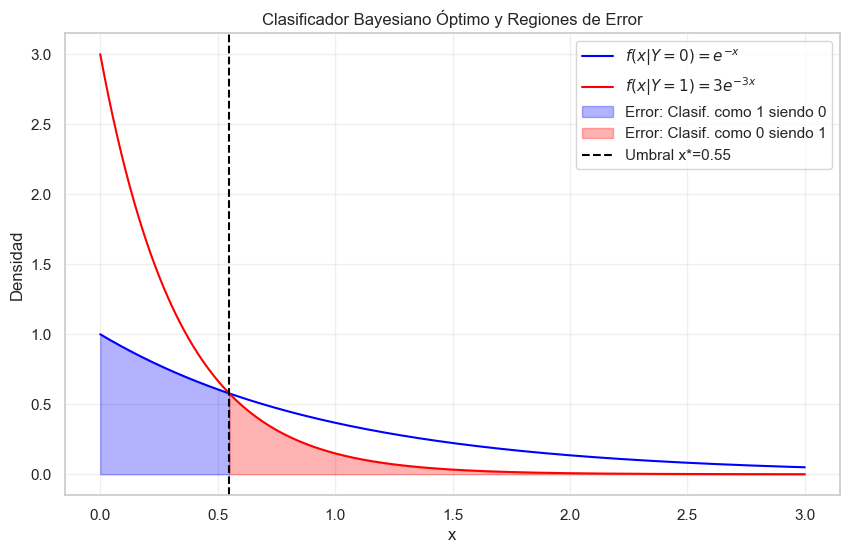

In [34]:
# Definir las funciones de densidad
def f0(x):
    return np.exp(-x) if x >= 0 else 0

def f1(x):
    return 3 * np.exp(-3 * x) if x >= 0 else 0

# Punto de intersección teórico
x_star = np.log(3) / 2

# Calcular el error teóricamente (Priors asimidos iguales = 0.5)
# Error = 0.5 * Integral(f0 en R1) + 0.5 * Integral(f1 en R0)
error_tipo_1, _ = quad(f0, 0, x_star)        # Clasificar como 1 siendo 0
error_tipo_2, _ = quad(f1, x_star, np.inf)   # Clasificar como 0 siendo 1

total_error = 0.5 * error_tipo_1 + 0.5 * error_tipo_2

print(f"Punto de corte óptimo (x*): {x_star:.4f}")
print(f"Probabilidad de Error Total: {total_error:.4f}")

# Graficar
x_vals = np.linspace(0, 3, 500)
y_f0 = [f0(x) for x in x_vals]
y_f1 = [f1(x) for x in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_f0, label=r'$f(x|Y=0) = e^{-x}$', color='blue')
plt.plot(x_vals, y_f1, label=r'$f(x|Y=1) = 3e^{-3x}$', color='red')

# Sombrear regiones de error
x_fill_1 = np.linspace(0, x_star, 100)
plt.fill_between(x_fill_1, [f0(x) for x in x_fill_1], color='blue', alpha=0.3, label='Error: Clasif. como 1 siendo 0')

x_fill_2 = np.linspace(x_star, 3, 100)
plt.fill_between(x_fill_2, [f1(x) for x in x_fill_2], color='red', alpha=0.3, label='Error: Clasif. como 0 siendo 1')

plt.axvline(x_star, color='black', linestyle='--', label=f'Umbral x*={x_star:.2f}')
plt.title('Clasificador Bayesiano Óptimo y Regiones de Error')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
### Inciso 3.

La siguiente tabla de datos muestra información de la decisión de jugar o no jugar golf, en función de varios factores como el tipo de clima, temperatura, humedad, o si hay viento, para 14 observaciones diferentes.

| Obs | Outlook   | Temperature | Humidity | Windy | Play Golf? |
|-----|-----------|------------|----------|-------|------------|
| 0   | Rainy     | Hot        | High     | False | No         |
| 1   | Rainy     | Hot        | High     | True  | No         |
| 2   | Overcast  | Hot        | High     | False | Yes        |
| 3   | Sunny     | Mild       | High     | False | Yes        |
| 4   | Sunny     | Cool       | Normal   | False | Yes        |
| 5   | Sunny     | Cool       | Normal   | True  | No         |
| 6   | Overcast  | Cool       | Normal   | True  | Yes        |
| 7   | Rainy     | Mild       | High     | False | No         |
| 8   | Rainy     | Cool       | Normal   | False | Yes        |
| 9   | Sunny     | Mild       | Normal   | False | Yes        |
| 10  | Rainy     | Mild       | Normal   | True  | Yes        |
| 11  | Overcast  | Mild       | High     | True  | Yes        |
| 12  | Overcast  | Hot        | Normal   | False | Yes        |
| 13  | Sunny     | Mild       | High     | True  | No         |

Las variables son:

- $X_1$ = Outlook  
- $X_2$ = Temperature  
- $X_3$ = Humidity  
- $X_4$ = Windy  

Con base en la evidencia de la tabla, construya **dos** de los siguientes clasificadores:

- (a) KNN  
- (b) Naive Bayes  
- (c) Regresión logística  

para determinar si se debe o no jugar golf en los siguientes casos:

- $x = (\text{Rainy}, \text{Hot}, \text{High}, \text{False})$
- $x = (\text{Sunny}, \text{Hot}, \text{Normal}, \text{False})$



Compare el desempeño de sus dos clasificadores e indique con cuál se obtienen mejores resultados.  
Utilice métricas como:

- Accuracy  
- Precision  
- Recall  
- $F_1$ Score  
- ROC AUC  

para validar su argumento.




In [35]:
# 1. Recreando la tabla de datos de 14 observaciones
data = {
    'Outlook': ['Rainy', 'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Overcast', 'Sunny'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True, False, False, False, True, True, False, True],
    'Play_Golf': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

# 2. Transformar variables usando one-hot encoding
X = pd.get_dummies(df[['Outlook', 'Temperature', 'Humidity', 'Windy']], dtype=int)
y = df['Play_Golf'].map({'Yes': 1, 'No': 0})

# 3. Preparar los dos casos específicos a predecir
casos_prueba = pd.DataFrame({
    'Outlook': ['Rainy', 'Sunny'],
    'Temperature': ['Hot', 'Hot'],
    'Humidity': ['High', 'Normal'],
    'Windy': [False, False]
})

# Aplicar get_dummies y alinear las columnas con X para evitar errores de dimensión
X_prueba = pd.get_dummies(casos_prueba, dtype=int)
X_prueba = X_prueba.reindex(columns=X.columns, fill_value=0)

Clasificador 1: Naïve Bayes

¿Por qué lo escogimos?
1. Manejo de datos categóricos: Todas las variables independientes (Outlook, Temperature, Humidity, Windy) son puramente categóricas. Naïve Bayes es excepcionalmente bueno trabajando con este tipo de atributos calculando probabilidades condicionales directas.
2. Escasez de datos: La tabla solo cuenta con 14 observaciones. Naïve Bayes no requiere de grandes volúmenes de datos para estimar los parámetros necesarios para la clasificación (las probabilidades a priori y condicionales), lo que ayuda a responder la pregunta final del laboratorio sobre cómo construir modelos con pocos datos.

In [36]:
# Entrenar el modelo
nb_model = CategoricalNB()
nb_model.fit(X, y)

# Calcular predicciones para el set de datos
y_pred_nb = nb_model.predict(X)
y_prob_nb = nb_model.predict_proba(X)[:, 1]
pred_casos_nb = nb_model.predict(X_prueba)

# Mostrar Métricas
print("--- MÉTRICAS NAÏVE BAYES ---")
print(f"Accuracy:  {accuracy_score(y, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y, y_pred_nb):.4f}")
print(f"F1 Score:  {f1_score(y, y_pred_nb):.4f}")
print(f"ROC AUC:   {roc_auc_score(y, y_prob_nb):.4f}")

# Mostrar Predicciones solicitadas
print("\n--- PREDICCIONES DE LOS CASOS ---")
print(f"x = (Rainy, Hot, High, False) -> ¿Play Golf?: {'Yes' if pred_casos_nb[0]==1 else 'No'}")
print(f"x = (Sunny, Hot, Normal, False) -> ¿Play Golf?: {'Yes' if pred_casos_nb[1]==1 else 'No'}")

--- MÉTRICAS NAÏVE BAYES ---
Accuracy:  0.8571
Precision: 0.8889
Recall:    0.8889
F1 Score:  0.8889
ROC AUC:   0.8889

--- PREDICCIONES DE LOS CASOS ---
x = (Rainy, Hot, High, False) -> ¿Play Golf?: No
x = (Sunny, Hot, Normal, False) -> ¿Play Golf?: Yes


Clasificador 2: Regresión Logística

¿Por qué lo escogimos?
1. Naturaleza binaria del problema: La variable objetivo "Play Golf?" es estrictamente binaria (Yes/No), y la regresión logística está diseñada matemáticamente y optimizada exactamente para este tipo de salidas.
2. Evaluación con ROC AUC: El laboratorio pide comparar los modelos utilizando métricas como ROC AUC. La Regresión Logística es un modelo probabilístico que por naturaleza devuelve una probabilidad continua entre 0 y 1 antes de aplicar el umbral de decisión, lo que hace que trazar y evaluar la curva ROC sea muy natural y preciso en comparación con KNN, el cual puede ser más rígido con las probabilidades.

In [37]:
# Entrenar el modelo
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X, y)

# Calcular predicciones para el set de datos
y_pred_lr = lr_model.predict(X)
y_prob_lr = lr_model.predict_proba(X)[:, 1]
pred_casos_lr = lr_model.predict(X_prueba)

# Mostrar Métricas
print("--- MÉTRICAS REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy:  {accuracy_score(y, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y, y_pred_lr):.4f}")
print(f"ROC AUC:   {roc_auc_score(y, y_prob_lr):.4f}")

# Mostrar Predicciones solicitadas
print("\n--- PREDICCIONES DE LOS CASOS ---")
print(f"x = (Rainy, Hot, High, False) -> ¿Play Golf?: {'Yes' if pred_casos_lr[0]==1 else 'No'}")
print(f"x = (Sunny, Hot, Normal, False) -> ¿Play Golf?: {'Yes' if pred_casos_lr[1]==1 else 'No'}")

--- MÉTRICAS REGRESIÓN LOGÍSTICA ---
Accuracy:  0.8571
Precision: 0.8182
Recall:    1.0000
F1 Score:  0.9000
ROC AUC:   0.9778

--- PREDICCIONES DE LOS CASOS ---
x = (Rainy, Hot, High, False) -> ¿Play Golf?: No
x = (Sunny, Hot, Normal, False) -> ¿Play Golf?: Yes


### Resultados de Predicción
Ambos modelos coinciden en los casos de prueba:
1.  `(Rainy, Hot, High, False)` → **No Jugar**
2.  `(Sunny, Hot, Normal, False)` → **Sí Jugar**

### Conclusiones
La **Regresión Logística** resulta ser el modelo superior para este caso, ya que alcanza un **ROC AUC de 0.9778** y un **Recall de 1.0**, demostrando una capacidad casi perfecta para separar las clases y no omitir ningún caso positivo ("Yes").



Responda la siguiente pregunta:

**¿Cómo construir un clasificador bueno, con tan pocos datos?**


Para construir modelos confiables con muestras mínimas (N=14):
1.  **Simplicidad:** Usar modelos con "fuerte sesgo" (como los probados) que evitan el sobreajuste (overfitting).
2.  **Codificación:** Transformar variables categóricas correctamente (One-Hot Encoding).
3.  **Métricas Robustas:** No fiarse solo del Accuracy; priorizar F1-Score y ROC AUC para entender la capacidad real de distinción del modelo.


---
### Inciso 4. 

Construir un clasificador binario para el siguiente conjunto de datos de **Spam / No Spam**:

https://www.kaggle.com/datasets/alexandercarreo/es-spamham-dataset-para-deteccion-de-spam?select=spam_ham_es_dataset_v1.csv

Usted puede elegir cualquiera de los algoritmos vistos en clase para construir su clasificador, pero el objetivo es utilizar aquel con mejor desempeño (menor error) posible.

Utilice métricas como:

- Accuracy  
- Precision  
- Recall  
- $F_1$ Score  
- ROC AUC  
- Binary Crossentropy  

para validar el desempeño de su clasificador.


Para ello, cuando su algoritmo así lo requiera, deberá construir un *embedding* adecuado de sus textos a un vector numérico.

### Sugerencias:

- No olvide hacer un uso adecuado del conjunto de entrenamiento, el conjunto de validación y el conjunto de prueba.
- Uso de técnicas de validación cruzada para una buena medición del desempeño.
- Se sugiere el uso de técnicas de procesamiento de lenguaje natural (NLP). Investigue en qué consiste y para qué sirven los siguientes conceptos, y aplíquelos en su clasificador si lo considera conveniente:

  - Remoción de *stopwords*  
  - Uso de *lemmatization*  
  - Uso de vectorizaciones:
    - Bag of Words  
    - TF-IDF  
    - Doc2Vec


#### 1. Análisis Exploratorio de Datos (EDA)
Primero, cargaremos el dataset y exploraremos la distribución de las clases y la longitud de los mensajes.

,tipo,texto
0,spam,¡Felicidades! Ganaste un iPhone completamente ...
1,spam,Gana $500 al día trabajando desde casa. Regíst...
2,spam,Tu cuenta será suspendida. Verifica tu informa...
3,spam,Oferta limitada: consigue medicamentos con 70%...
4,spam,Has sido seleccionado para un premio exclusivo...


C:\Users\linar\AppData\Local\Temp\ipykernel_6300\708631270.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tipo', palette='Set2')


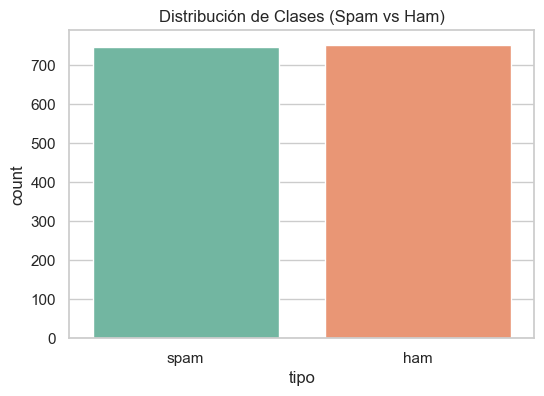


Conteo exacto por clase:
tipo
ham     752
spam    747
Name: count, dtype: int64


In [38]:
# Cargar el dataset
df = pd.read_csv('spam_ham_es_dataset_v1.csv')

display(df.head())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='tipo', palette='Set2')
plt.title('Distribución de Clases (Spam vs Ham)')
plt.show()

print("\nConteo exacto por clase:")
print(df['tipo'].value_counts())

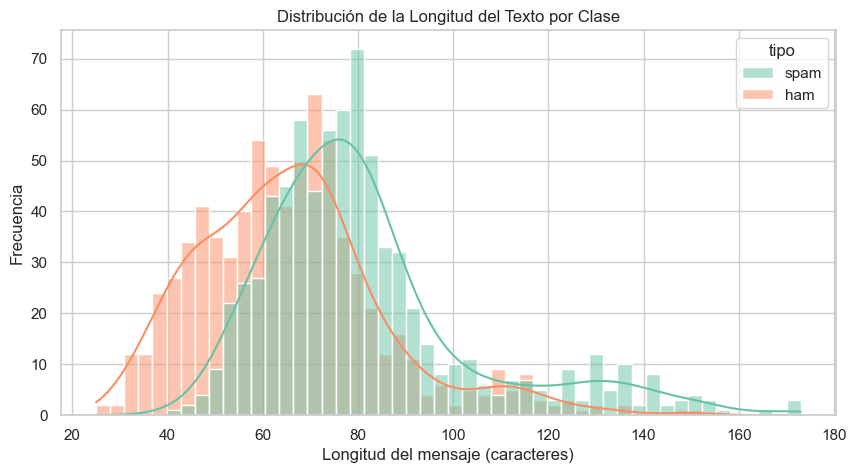

In [39]:
# Calcular la longitud de cada mensaje
df['longitud_texto'] = df['texto'].apply(len)

# Visualizar la distribución de la longitud de los mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='longitud_texto', hue='tipo', kde=True, palette='Set2', bins=50)
plt.title('Distribución de la Longitud del Texto por Clase')
plt.xlabel('Longitud del mensaje (caracteres)')
plt.ylabel('Frecuencia')
plt.show()

#### 2. Preprocesamiento de Datos y Representación de Texto
Separaremos nuestros datos en conjuntos de entrenamiento y prueba. Luego, aplicaremos tokenización, eliminación de *stop words* y convertiremos el texto en una matriz numérica utilizando **TF-IDF** (Term Frequency-Inverse Document Frequency), como se vio en la Semana 2.

In [40]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df['texto']
y = df['tipo']

# División en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

stop_words_es = stopwords.words('spanish')

# Inicializar el vectorizador TF-IDF
vectorizer = TfidfVectorizer(stop_words=stop_words_es, lowercase=True)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Dimensiones de la matriz de entrenamiento: {X_train_vec.shape}")
print(f"Dimensiones de la matriz de prueba: {X_test_vec.shape}")

Dimensiones de la matriz de entrenamiento: (1199, 2997)
Dimensiones de la matriz de prueba: (300, 2997)


#### 3. Entrenamiento de Modelos
Entrenaremos dos modelos de clasificación estadística vistos en la Semana 3:
1. **Regresión Logística**
2. **Multinomial Naive Bayes** (ideal para conteos de palabras y TF-IDF)

In [41]:
# 1. Instanciar y entrenar Regresión Logística
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_vec, y_train)

# 2. Instanciar y entrenar Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

print("¡Modelos entrenados con éxito!")

¡Modelos entrenados con éxito!


#### 4. Evaluación de Modelos
Evaluaremos el rendimiento de ambos modelos utilizando las predicciones sobre el conjunto de prueba. Calcularemos las métricas: *Accuracy*, *Precision*, *Recall*, *F1-Score* y visualizaremos las *Matrices de Confusión*.

REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

         ham       0.97      0.95      0.96       151
        spam       0.95      0.97      0.96       149

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

ROC AUC Score:         0.9904
Binary Crossentropy:   0.3570


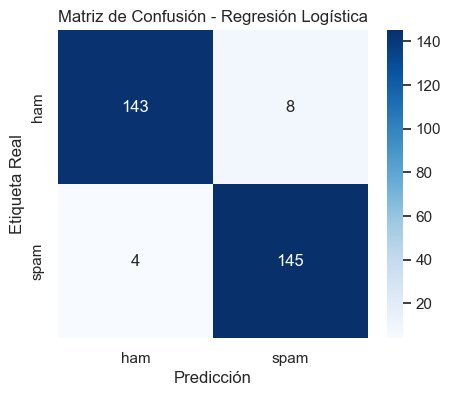

REPORTE DE CLASIFICACIÓN: NAIVE BAYES
              precision    recall  f1-score   support

         ham       0.97      0.93      0.95       151
        spam       0.93      0.97      0.95       149

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

ROC AUC Score:         0.9918
Binary Crossentropy:   0.2434


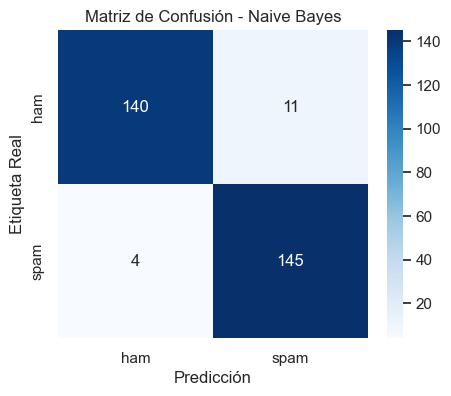

In [42]:
y_pred_lr = lr_model.predict(X_test_vec)
y_prob_lr = lr_model.predict_proba(X_test_vec)[:, 1]

y_pred_nb = nb_model.predict(X_test_vec)
y_prob_nb = nb_model.predict_proba(X_test_vec)[:, 1]

y_test_bin = y_test.map({'ham': 0, 'spam': 1})

# Función para plotear matriz de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['ham', 'spam'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    plt.title(title)
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.show()

# Evaluar Regresión Logística
print("="*50)
print("REPORTE DE CLASIFICACIÓN: REGRESIÓN LOGÍSTICA")
print("="*50)
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC Score:         {roc_auc_score(y_test_bin, y_prob_lr):.4f}")
print(f"Binary Crossentropy:   {log_loss(y_test_bin, y_prob_lr):.4f}")
plot_confusion_matrix(y_test, y_pred_lr, 'Matriz de Confusión - Regresión Logística')

# Evaluar Naive Bayes
print("="*50)
print("REPORTE DE CLASIFICACIÓN: NAIVE BAYES")
print("="*50)
print(classification_report(y_test, y_pred_nb))
print(f"ROC AUC Score:         {roc_auc_score(y_test_bin, y_prob_nb):.4f}")
print(f"Binary Crossentropy:   {log_loss(y_test_bin, y_prob_nb):.4f}")
plot_confusion_matrix(y_test, y_pred_nb, 'Matriz de Confusión - Naive Bayes')

#### 5. Análisis y Conclusiones

**¿Qué modelo tuvo un mejor desempeño en la detección de spam?**
Al analizar las métricas de clasificación directa (Accuracy, Precision, Recall, F1-Score), el modelo de **Regresión Logística** demostró tener un desempeño superior, alcanzando una exactitud general del **96%**, frente al 95% de **Multinomial Naive Bayes**. Además, la Regresión Logística logró un mejor balance en el F1-Score para ambas clases.

Sin embargo, al evaluar las probabilidades subyacentes con las nuevas métricas, la historia se vuelve interesante:
* **ROC AUC:** Ambos modelos son excelentes separando las clases (superiores a 0.99), pero Naive Bayes es marginalmente mejor (0.9918 vs 0.9904).
* **Binary Crossentropy (Log Loss):** Aquí **Naive Bayes** gana de forma clara con un error mucho menor (0.2434) comparado con Regresión Logística (0.3570). Esto indica que Naive Bayes no solo clasifica bien, sino que sus probabilidades predichas tienen mayor certidumbre.

**Importancia de los Falsos Positivos vs Falsos Negativos:**
En el contexto de la detección de correos, los errores no tienen el mismo impacto:
* **Falso Positivo (Predecir Spam cuando es Ham):** Este es el error **más crítico**. Significa que un mensaje legítimo o importante de un usuario se enviará a la bandeja de correo no deseado y podría perderse, causando problemas graves de comunicación.
* **Falso Negativo (Predecir Ham cuando es Spam):** Un mensaje no deseado llega a la bandeja de entrada principal. Aunque es molesto, es menos destructivo que el caso anterior.

**Conclusión Final:**
En nuestro caso, la **Precisión (Precision)** para la clase `spam` es la métrica más importante, ya que una alta precisión nos asegura que habrá menos Falsos Positivos. 
A pesar de que Naive Bayes tiene un menor Log Loss y un excelente ROC AUC, la **Regresión Logística** logra una mejor precisión directa en el umbral por defecto (**0.95** frente a **0.93**). Por lo tanto, desde el punto de vista de la experiencia del usuario (evitar perder correos legítimos), la **Regresión Logística es el modelo más adecuado** para poner en producción en este pipeline.